# Architecture Inspection — Information Flow in SlotODE

Trace every intermediate activation through the model to understand what each component learns and how information flows from pixels to slot velocities.

**Pipeline:**
```
Image [B, 3, 64, 64]
  → CNN Encoder (4x conv+ReLU) → [B, 64, 64, 64]
  → Positional Embedding → [B, 64, 64, 64]
  → Flatten + LayerNorm + MLP → enc_feat [B, 4096, 64]
  → Linear projections → K [B, 4096, 64], V [B, 4096, 64]

Slots_0 ~ N(mu, sigma) → [B, 11, 64]

ODE Vector Field f(slots):
  → LayerNorm(slots) → slots_norm
  → slots_norm @ W_q → Q [B, 11, 64]
  → softmax(Q @ K^T / sqrt(d), axis=slots) → A [B, 11, 4096]  (slot-normalized)
  → A / sum(A, axis=features) → A_hat  (row-normalized)
  → A_hat @ V → f_attn [B, 11, 64]  (what attention reads)
  → sigmoid([slots_norm, f_attn] @ W_gate) → gate [B, 11, 64]  (how much to use it)
  → LayerNorm(slots) → slots_ff
  → ReLU([slots_ff, f_attn] @ W_ff0) @ W_ff1 → h [B, 11, 64]  (MLP residual)
  → gate * f_attn + h → velocity [B, 11, 64]
```

In [1]:
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import equinox as eqx
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from model import SlotODEModel

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8, "grid.linewidth": 0.4, "grid.alpha": 0.3,
    "lines.linewidth": 1.5, "figure.facecolor": "white",
})
SLOT_CMAP = sns.color_palette("husl", 11)

In [2]:
# ── load model + one image ──────────────────────────────────────────────────
CKPT_PATH = "runs_data/omkos-slotode/slot_ode_11_slots_euler_T3_dt0.5/checkpoints/best.eqx"
META_PATH = CKPT_PATH.replace(".eqx", "_meta.pkl")

with open(META_PATH, "rb") as f:
    meta = pickle.load(f)
ckpt_args = meta["args"]

model = SlotODEModel(
    resolution=(64, 64),
    num_slots=ckpt_args["num_slots"], slot_dim=ckpt_args["slot_dim"],
    enc_hidden_dim=ckpt_args["enc_hidden_dim"],
    num_iter=ckpt_args["num_iter"], dt0=ckpt_args["dt"],
    key=jax.random.key(0),
)
model = eqx.tree_deserialise_leaves(CKPT_PATH, model)
model = eqx.nn.inference_mode(model)

N_SLOTS = ckpt_args["num_slots"]
SLOT_DIM = ckpt_args["slot_dim"]
H, W = 64, 64

# load a single image
DATA_DIR = Path("CLEVR_64")
val_imgs = sorted((DATA_DIR / "images" / "val").glob("*.png"))
np.random.seed(7)
img_path = val_imgs[np.random.randint(len(val_imgs))]

img_np = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
img_display = img_np.copy()
img_np = img_np * 2.0 - 1.0
img_jax = jnp.array(img_np.transpose(2, 0, 1))[None]  # [1, 3, 64, 64]
print(f"Image: {img_path.name}, shape: {img_jax.shape}")

# quick forward pass for masks reference
key = jax.random.key(42)
recon, masks, slots, traj = model(img_jax, key=key, return_traj=True)
traj_np = np.array(traj)
masks_np = np.array(masks)
print(f"Trajectory: {traj_np.shape}, Masks: {masks_np.shape}")

Image: 004271.png, shape: (1, 3, 64, 64)


E0409 15:35:41.152990   24409 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Trajectory: (7, 1, 11, 64), Masks: (1, 11, 64, 64)


## 1. CNN Encoder — What Does Each Layer Learn?

The encoder is 4 conv layers (5x5 kernels, stride 1, padding 2) with ReLU, followed by positional embedding, LayerNorm, and a residual MLP. All layers preserve spatial resolution (64x64).

We extract feature maps after each conv layer to see what the network detects at each stage.

In [3]:
# ── Extract intermediate CNN activations ────────────────────────────────────
enc = model.enc
img_single = img_jax[0]  # [3, 64, 64] — single image, no batch

# layer by layer (encode_single logic from Encoder.__call__)
conv0_out = jax.nn.relu(enc.conv0(img_single))   # [64, 64, 64]
conv1_out = jax.nn.relu(enc.conv1(conv0_out))     # [64, 64, 64]
conv2_out = jax.nn.relu(enc.conv2(conv1_out))     # [64, 64, 64]
conv3_out = jax.nn.relu(enc.conv3(conv2_out))     # [64, 64, 64]

# positional embedding (needs batch dim)
post_pos = enc.pos(conv3_out[None])[0]  # [64, 64, 64]

# flatten + MLP
flat = post_pos.reshape(SLOT_DIM, H * W).transpose(1, 0)  # [4096, 64]
h_norm = jax.vmap(enc.norm)(flat)
h_mlp = jax.vmap(enc.fc0)(h_norm)
h_mlp = jax.nn.relu(h_mlp)
h_mlp = jax.vmap(enc.fc1)(h_mlp)
enc_feat_single = flat + h_mlp  # [4096, 64] — final encoder output

conv_outputs = {
    "Input": np.array(img_single),           # [3, 64, 64]
    "Conv 0 + ReLU": np.array(conv0_out),    # [64, 64, 64]
    "Conv 1 + ReLU": np.array(conv1_out),
    "Conv 2 + ReLU": np.array(conv2_out),
    "Conv 3 + ReLU": np.array(conv3_out),
    "After PosEmbed": np.array(post_pos),
    "After MLP (enc_feat)": np.array(enc_feat_single.reshape(H, W, SLOT_DIM).transpose(2, 0, 1)),
}

for name, feat in conv_outputs.items():
    print(f"{name:25s} shape={str(feat.shape):20s} mean={feat.mean():.4f}  std={feat.std():.4f}  "
          f"[{feat.min():.3f}, {feat.max():.3f}]")

Input                     shape=(3, 64, 64)          mean=-0.1143  std=0.2266  [-0.890, 0.255]
Conv 0 + ReLU             shape=(64, 64, 64)         mean=0.0112  std=0.0416  [0.000, 0.754]
Conv 1 + ReLU             shape=(64, 64, 64)         mean=0.0232  std=0.0874  [0.000, 1.820]
Conv 2 + ReLU             shape=(64, 64, 64)         mean=0.1641  std=0.5173  [0.000, 7.515]
Conv 3 + ReLU             shape=(64, 64, 64)         mean=2.9078  std=18.0507  [0.000, 296.884]
After PosEmbed            shape=(64, 64, 64)         mean=2.8715  std=18.2031  [-1.403, 297.597]
After MLP (enc_feat)      shape=(64, 64, 64)         mean=2.8851  std=18.9004  [-4.242, 303.770]


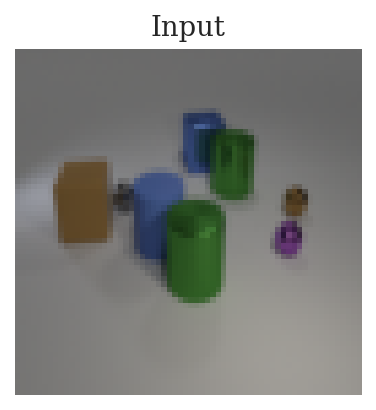

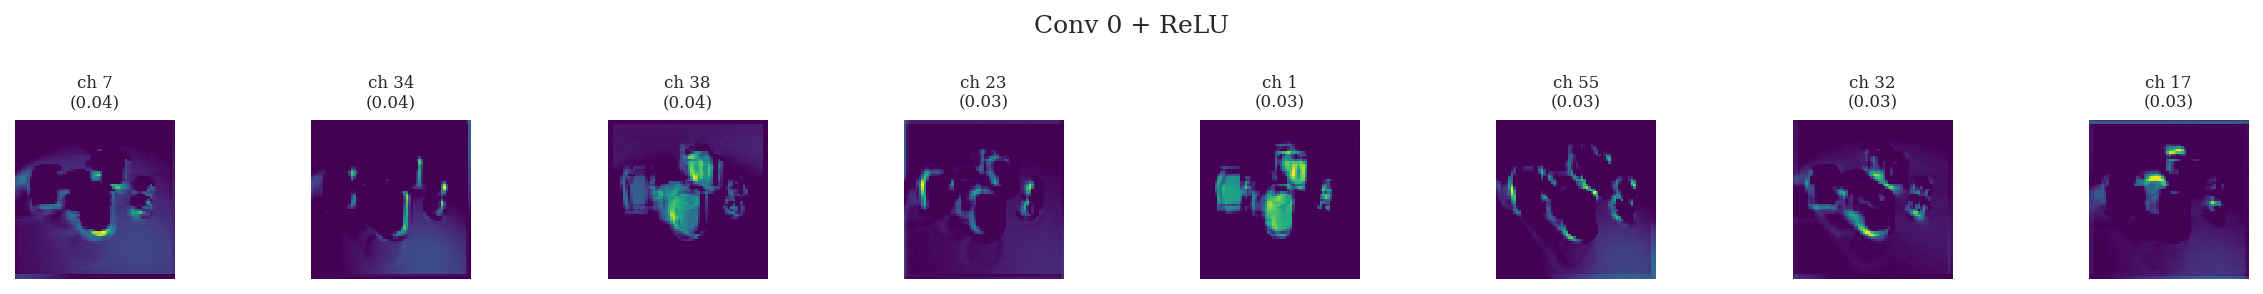

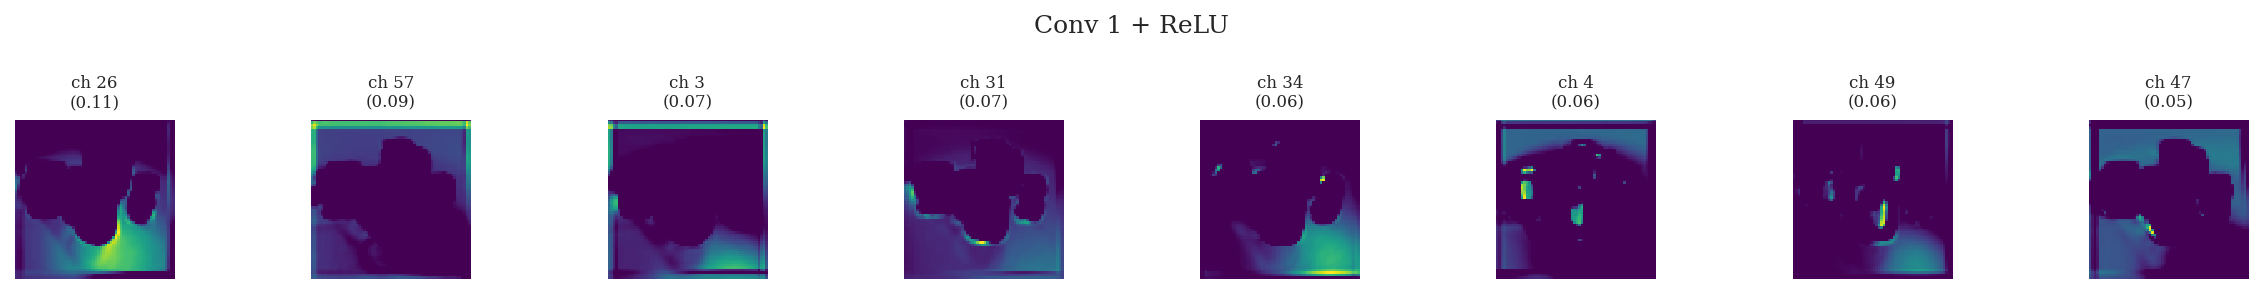

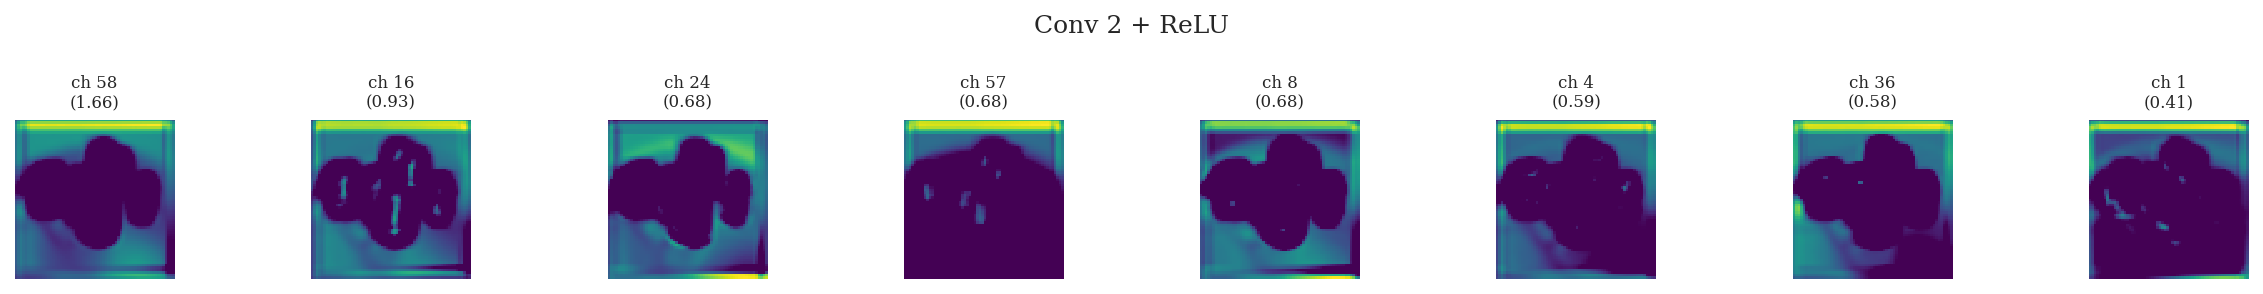

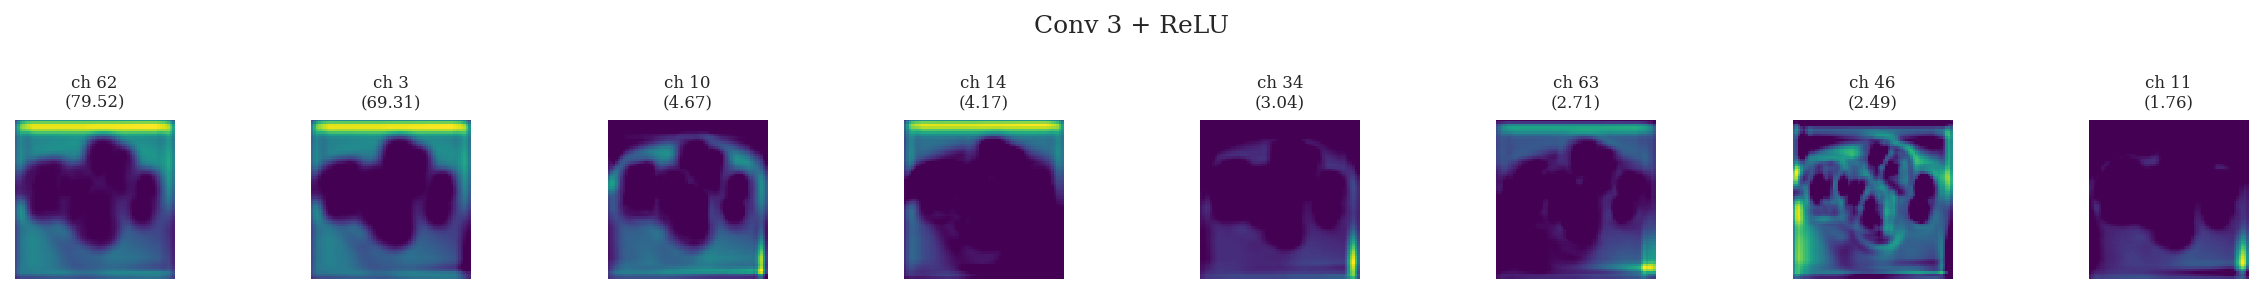

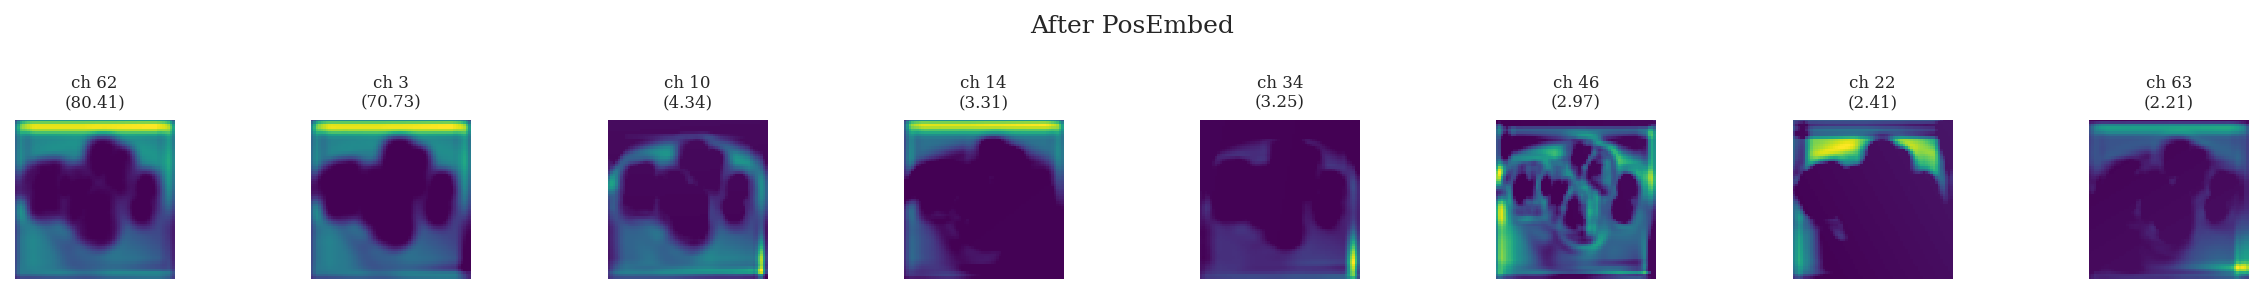

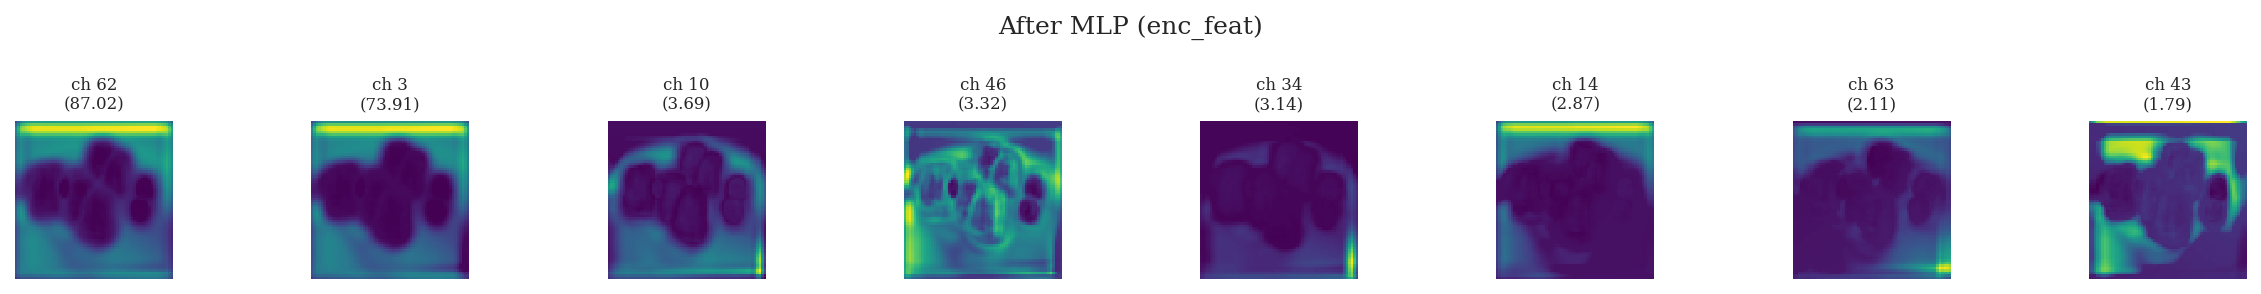

In [4]:
# ── Figure: CNN feature maps — show top-8 most active channels per layer ────

def show_feature_maps(feat, title, n_show=8):
    """feat: [C, H, W]. Show the n_show channels with highest mean activation."""
    C = feat.shape[0]
    if C == 3:
        # input image — show as RGB
        fig, ax = plt.subplots(1, 1, figsize=(3, 3))
        ax.imshow(np.clip((feat.transpose(1, 2, 0) + 1) / 2, 0, 1))
        ax.set_title(title)
        ax.axis("off")
        plt.show()
        return

    # rank channels by mean activation
    channel_means = feat.mean(axis=(1, 2))
    top_channels = np.argsort(channel_means)[::-1][:n_show]

    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2, 2))
    for ax, ch in zip(axes, top_channels):
        im = ax.imshow(feat[ch], cmap="viridis", interpolation="nearest")
        ax.set_title(f"ch {ch}\n({channel_means[ch]:.2f})", fontsize=8)
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()

for name, feat in conv_outputs.items():
    show_feature_maps(feat, name)

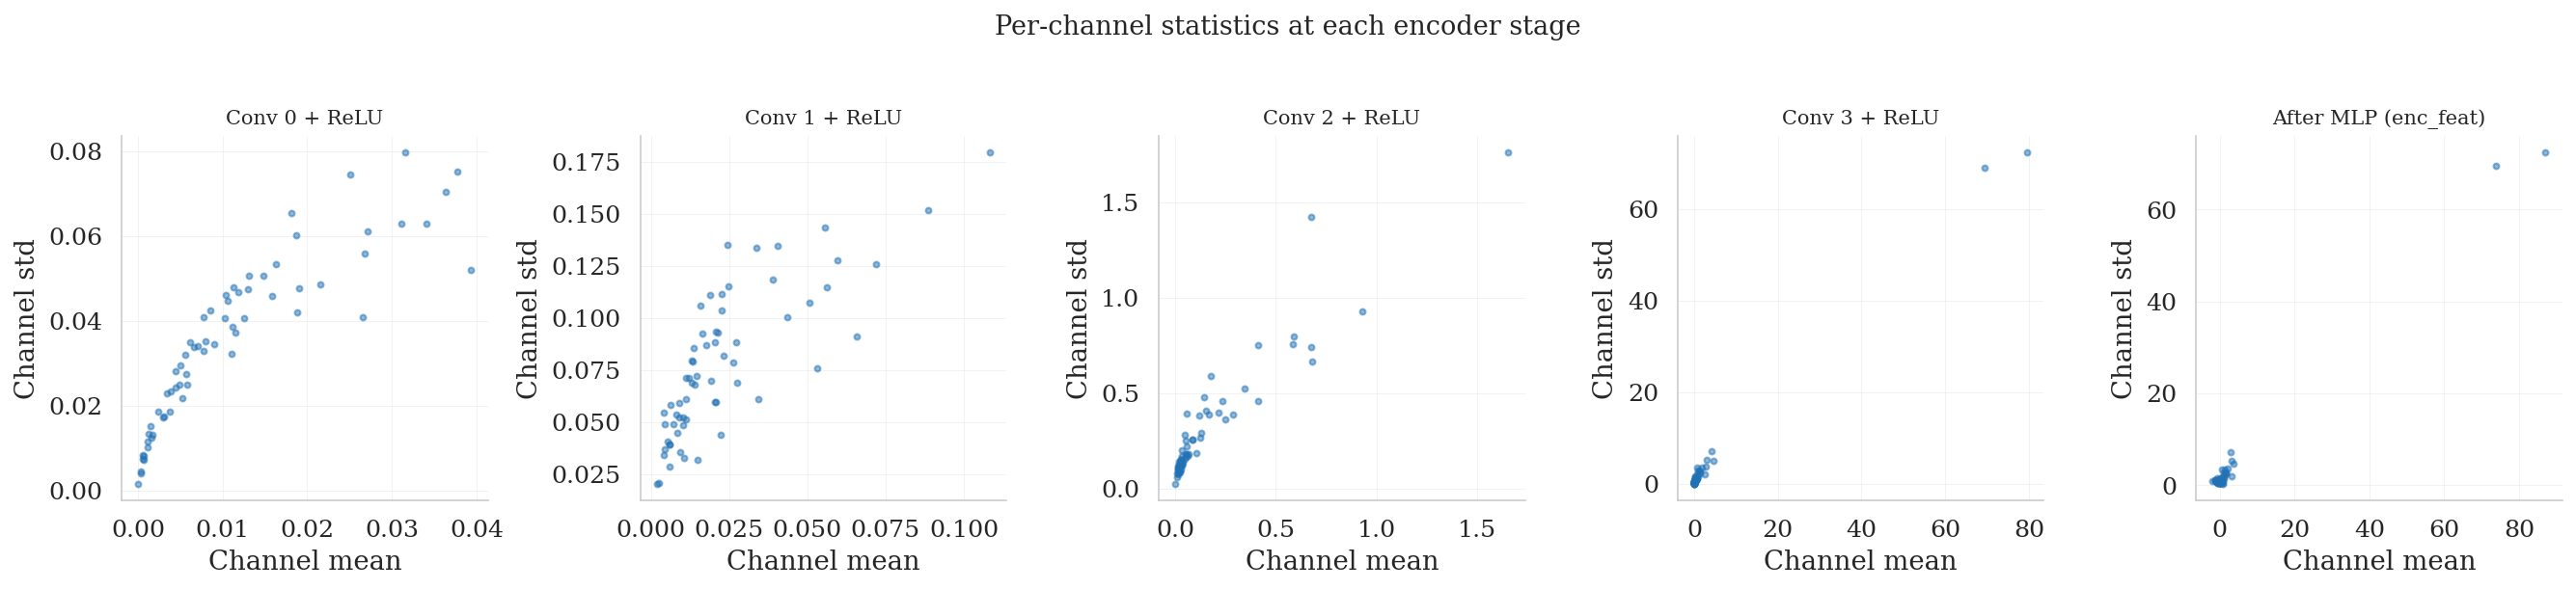

In [5]:
# ── Figure: Channel activation distribution per layer (violin plot) ─────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

layer_names = ["Conv 0 + ReLU", "Conv 1 + ReLU", "Conv 2 + ReLU", "Conv 3 + ReLU", "After MLP (enc_feat)"]
for ax, name in zip(axes, layer_names):
    feat = conv_outputs[name]  # [C, H, W]
    channel_means = feat.mean(axis=(1, 2))
    channel_stds = feat.std(axis=(1, 2))
    ax.scatter(channel_means, channel_stds, s=8, alpha=0.5, color="#2171b5")
    ax.set_xlabel("Channel mean")
    ax.set_ylabel("Channel std")
    ax.set_title(name, fontsize=10)

sns.despine()
fig.suptitle("Per-channel statistics at each encoder stage", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 2. Key and Value Spaces

K and V are precomputed once and fixed during integration. They *are* the scene representation that slots read from.

- **K** determines *what gets attended to* — keys that are similar to a slot's query get high attention weight
- **V** determines *what information is read* — the actual content that flows into f_attn

We visualize them spatially (reshape to 64x64) to see what structure the projections capture.

K: mean=0.1728, std=2.9154
V: mean=-0.1520, std=1.7490


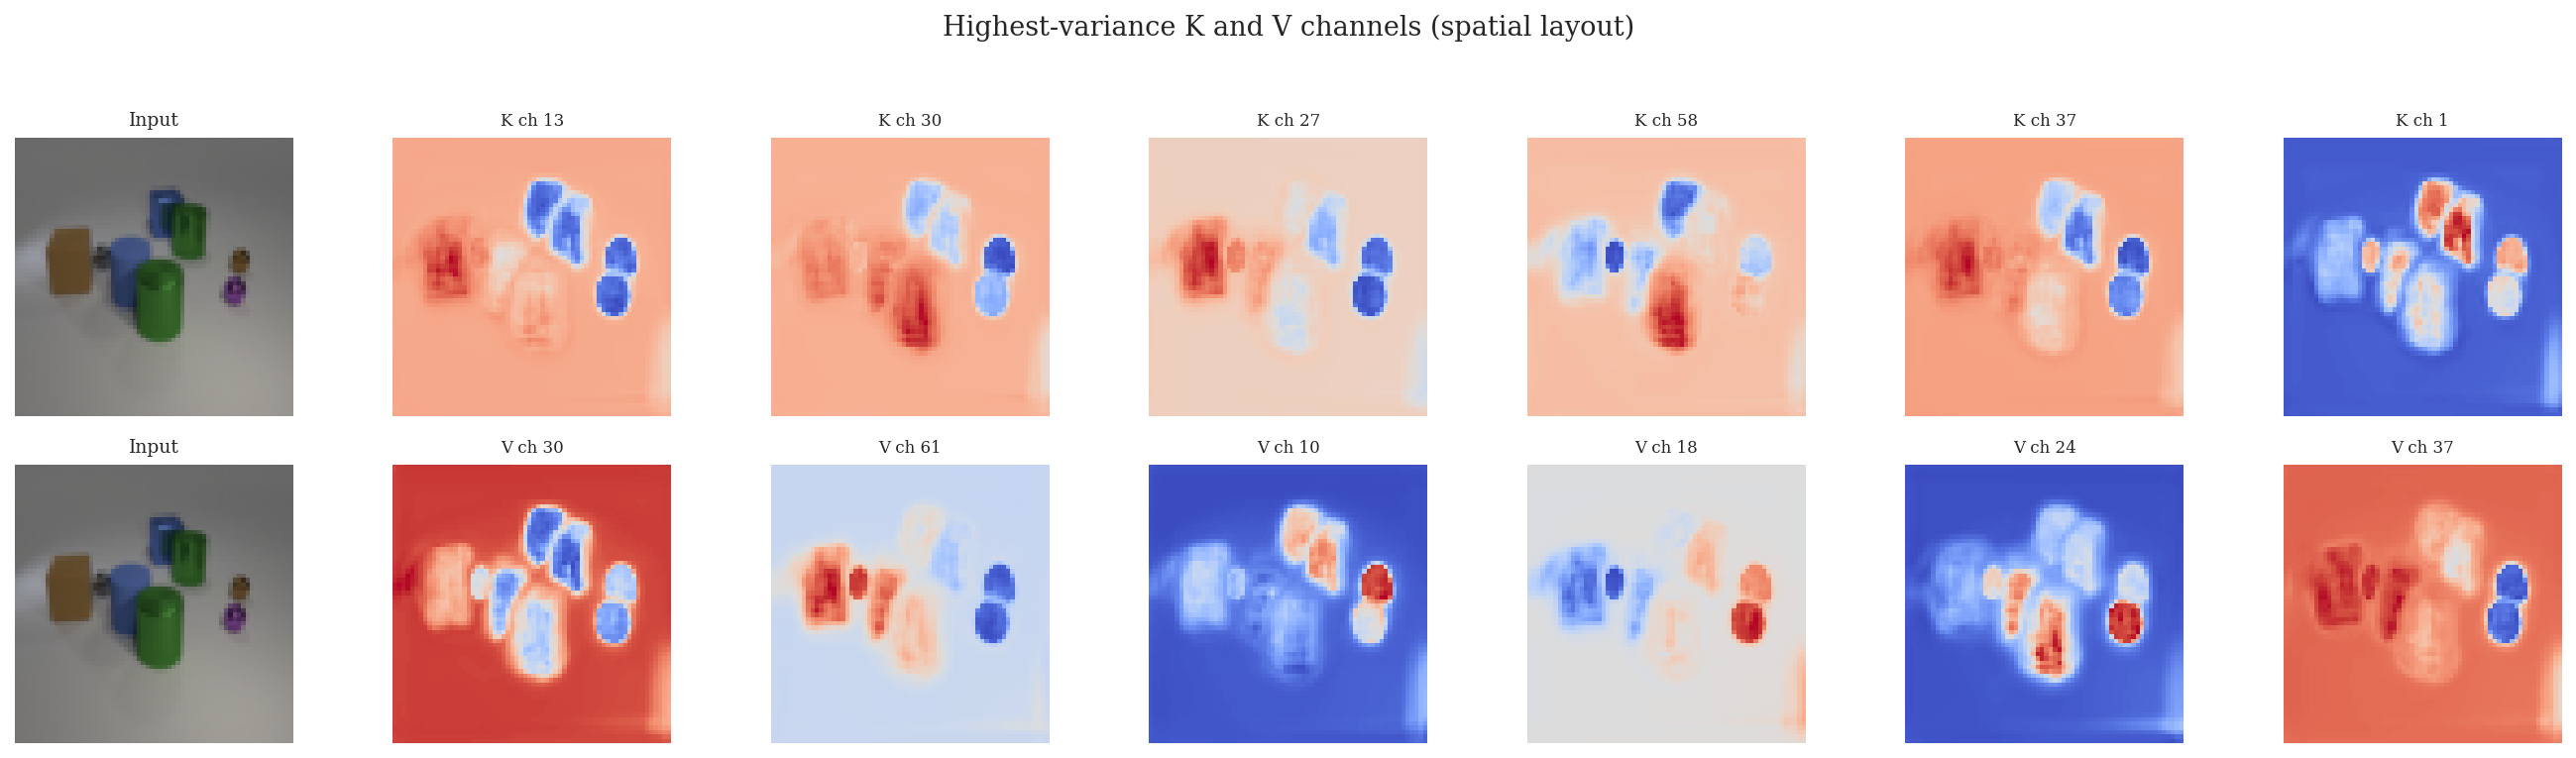

In [6]:
# ── Compute K, V from encoder features ──────────────────────────────────────
sa = model.slot_attention_ode
ode_func = sa.slot_ode_func

enc_feat_jax = model.enc(img_jax)  # [1, 4096, 64]
feat_norm_jax = jax.vmap(jax.vmap(sa.norm_input))(enc_feat_jax)
feat_jax = jax.vmap(jax.vmap(sa.fc_input))(feat_norm_jax)
k_jax = jax.vmap(jax.vmap(sa.to_k))(feat_jax)  # [1, 4096, 64]
v_jax = jax.vmap(jax.vmap(sa.to_v))(feat_jax)  # [1, 4096, 64]

k_np = np.array(k_jax[0])  # [4096, 64]
v_np = np.array(v_jax[0])

# reshape to spatial for visualization
k_spatial = k_np.reshape(H, W, SLOT_DIM).transpose(2, 0, 1)  # [64, 64, 64]
v_spatial = v_np.reshape(H, W, SLOT_DIM).transpose(2, 0, 1)

print(f"K: mean={k_np.mean():.4f}, std={k_np.std():.4f}")
print(f"V: mean={v_np.mean():.4f}, std={v_np.std():.4f}")

# ── Figure: top channels of K and V side by side ───────────────────────────
n_show = 6
fig, axes = plt.subplots(2, n_show + 1, figsize=(n_show * 2.5 + 3, 5))

# input image in first column
for row in range(2):
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title("Input", fontsize=9)
    axes[row, 0].axis("off")

# K channels
k_var = k_spatial.var(axis=(1, 2))
top_k = np.argsort(k_var)[::-1][:n_show]
for i, ch in enumerate(top_k):
    axes[0, i+1].imshow(k_spatial[ch], cmap="coolwarm", interpolation="nearest")
    axes[0, i+1].set_title(f"K ch {ch}", fontsize=8)
    axes[0, i+1].axis("off")

# V channels
v_var = v_spatial.var(axis=(1, 2))
top_v = np.argsort(v_var)[::-1][:n_show]
for i, ch in enumerate(top_v):
    axes[1, i+1].imshow(v_spatial[ch], cmap="coolwarm", interpolation="nearest")
    axes[1, i+1].set_title(f"V ch {ch}", fontsize=8)
    axes[1, i+1].axis("off")

axes[0, 1].set_ylabel("Keys (K)", fontsize=11)
axes[1, 1].set_ylabel("Values (V)", fontsize=11)
fig.suptitle("Highest-variance K and V channels (spatial layout)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## 3. Inside the ODE Vector Field — Attention, Gate, MLP at Each Time Step

For each trajectory point, we manually compute all intermediates of `f(slots)`:

| Symbol | Shape | What it is |
|---|---|---|
| `slots_norm` | [11, 64] | LayerNorm'd slots — input to attention query |
| `Q` | [11, 64] | Query vectors = slots_norm @ W_q |
| `A` | [11, 4096] | Attention weights (slot-normalized, then row-normalized) |
| `f_attn` | [11, 64] | What attention reads = A @ V |
| `gate` | [11, 64] | How much of f_attn to use = sigmoid([slots_norm, f_attn] @ W_gate) |
| `h` | [11, 64] | MLP residual = ReLU([slots_ff, f_attn] @ W_ff0) @ W_ff1 |
| `velocity` | [11, 64] | gate * f_attn + h |

In [7]:
# ── Manually compute all intermediates at each trajectory time step ──────────

def extract_intermediates(slots_1b, k_1b, v_1b):
    """
    Given slots [1, N_slots, D], k [1, N_feat, D], v [1, N_feat, D],
    return dict of all intermediate activations (no batch dim).
    """
    out = {}

    # LayerNorm for attention query
    slots_norm = jax.vmap(jax.vmap(ode_func.norm_attn))(slots_1b)
    out["slots_norm"] = np.array(slots_norm[0])  # [11, 64]

    # Query
    q = jnp.einsum('bnd,od->bno', slots_norm, ode_func.W_q)
    out["Q"] = np.array(q[0])  # [11, 64]

    # Attention logits and weights
    att_logits = jnp.einsum('bnd,bmd->bnm', q, k_1b) * ode_func.scale
    out["att_logits"] = np.array(att_logits[0])  # [11, 4096]

    att_slot_norm = jax.nn.softmax(att_logits, axis=1)  # softmax over slots
    out["att_slot_normalized"] = np.array(att_slot_norm[0])  # [11, 4096]

    att = att_slot_norm / (att_slot_norm.sum(axis=-1, keepdims=True) + 1e-8)
    out["att_final"] = np.array(att[0])  # [11, 4096] — row-normalized

    # f_attn — what attention reads
    f_attn = jnp.einsum('bnm,bmd->bnd', att, v_1b)
    out["f_attn"] = np.array(f_attn[0])  # [11, 64]

    # Gate
    gate_input = jnp.concatenate([slots_norm, f_attn], axis=-1)
    gate = jax.nn.sigmoid(jnp.einsum('bnd,od->bno', gate_input, ode_func.W_gate))
    out["gate"] = np.array(gate[0])  # [11, 64]

    # MLP residual (h)
    slots_ff = jax.vmap(jax.vmap(ode_func.norm_ff))(slots_1b)
    out["slots_ff"] = np.array(slots_ff[0])
    ff_input = jnp.concatenate([slots_ff, f_attn], axis=-1)
    h = jnp.einsum('bnd,od->bno', ff_input, ode_func.W_ff0)
    out["h_pre_relu"] = np.array(h[0])  # [11, 128]
    h = jax.nn.relu(h)
    out["h_post_relu"] = np.array(h[0])  # [11, 128]
    h = jnp.einsum('bnd,od->bno', h, ode_func.W_ff1)
    out["h"] = np.array(h[0])  # [11, 64]

    # Velocity
    velocity = gate * f_attn + h
    out["gate_times_f_attn"] = np.array((gate * f_attn)[0])  # [11, 64]
    out["velocity"] = np.array(velocity[0])  # [11, 64]

    return out

# compute at each trajectory time step
T_PTS = traj_np.shape[0]
time_values = np.arange(T_PTS) * ckpt_args["dt"]
intermediates = []

for t_idx in range(T_PTS):
    slots_t = jnp.array(traj_np[t_idx, 0:1])  # [1, 11, 64]
    inter = extract_intermediates(slots_t, k_jax, v_jax)
    intermediates.append(inter)

print(f"Extracted intermediates at {T_PTS} time steps.")
print(f"Keys: {list(intermediates[0].keys())}")

Extracted intermediates at 7 time steps.
Keys: ['slots_norm', 'Q', 'att_logits', 'att_slot_normalized', 'att_final', 'f_attn', 'gate', 'slots_ff', 'h_pre_relu', 'h_post_relu', 'h', 'gate_times_f_attn', 'velocity']


### 3a. Attention Maps — Which Pixels Does Each Slot Attend To?

The attention matrix A has shape [11, 4096]. Each row is a slot's attention distribution over spatial positions. We reshape to [11, 64, 64] to see spatial attention maps.

We show these at t=0 (initial), t=T/2, and t=T (terminal) to see how attention sharpens.

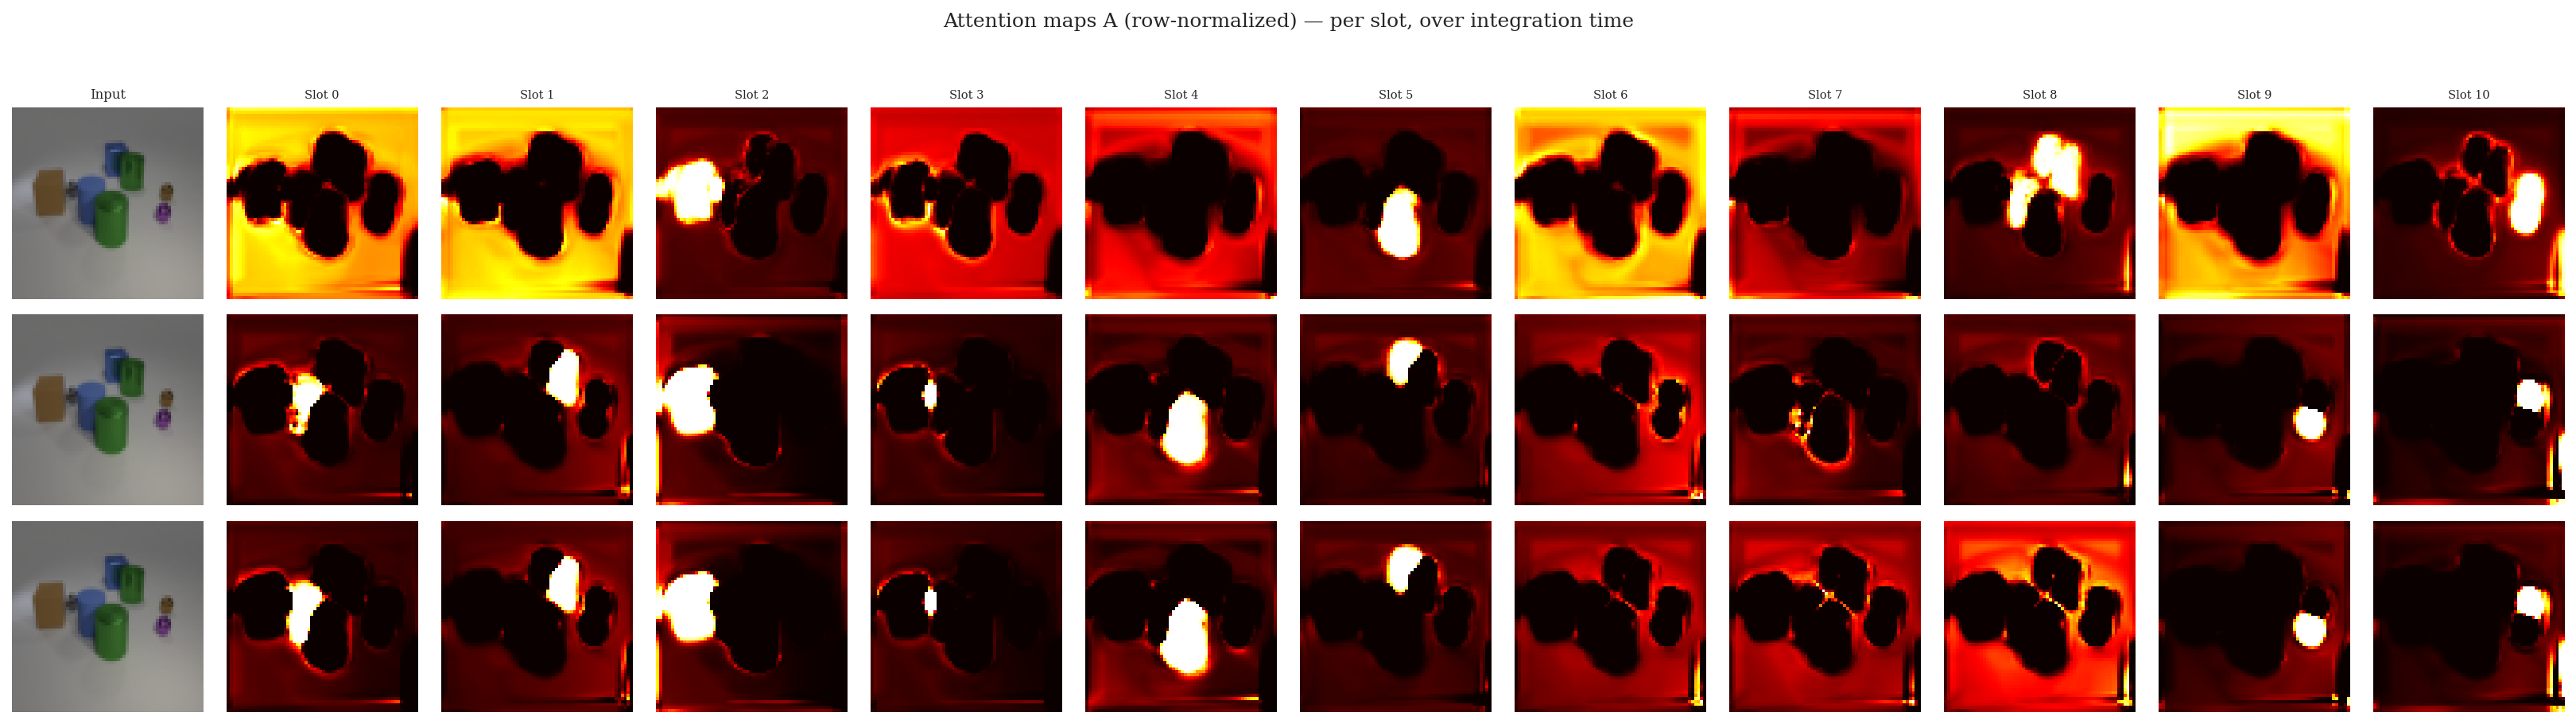

In [8]:
# ── Figure: Spatial attention maps at t=0, T/2, T ───────────────────────────
t_indices = [0, T_PTS // 2, T_PTS - 1]
t_labels = [f"$t = {time_values[ti]:.1f}$" for ti in t_indices]

fig, axes = plt.subplots(len(t_indices), N_SLOTS + 1, figsize=(N_SLOTS * 1.8 + 2, len(t_indices) * 2))

for row, (ti, label) in enumerate(zip(t_indices, t_labels)):
    # input image
    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title("Input" if row == 0 else "", fontsize=8)
    axes[row, 0].set_ylabel(label, fontsize=10)
    axes[row, 0].axis("off")

    att = intermediates[ti]["att_final"]  # [11, 4096]
    for s in range(N_SLOTS):
        att_map = att[s].reshape(H, W)
        axes[row, s + 1].imshow(att_map, cmap="hot", interpolation="nearest", vmin=0)
        if row == 0:
            axes[row, s + 1].set_title(f"Slot {s}", fontsize=7)
        axes[row, s + 1].axis("off")

fig.suptitle("Attention maps A (row-normalized) — per slot, over integration time", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

### 3b. Gate Values — What Does the Gate Learn to Control?

`gate = sigmoid([slots_norm, f_attn] @ W_gate)` — shape [11, 64].

Each entry is between 0 and 1. The gate controls *per-dimension* how much of the attention readout (f_attn) contributes to the velocity. A gate value near 0 means "ignore what attention read for this dimension." Near 1 means "pass it through."

Key questions:
- Is the gate uniform (all ~0.5) or structured (some dims gated in, others out)?
- Does gating pattern change over integration time?
- Do different slots have different gating patterns?

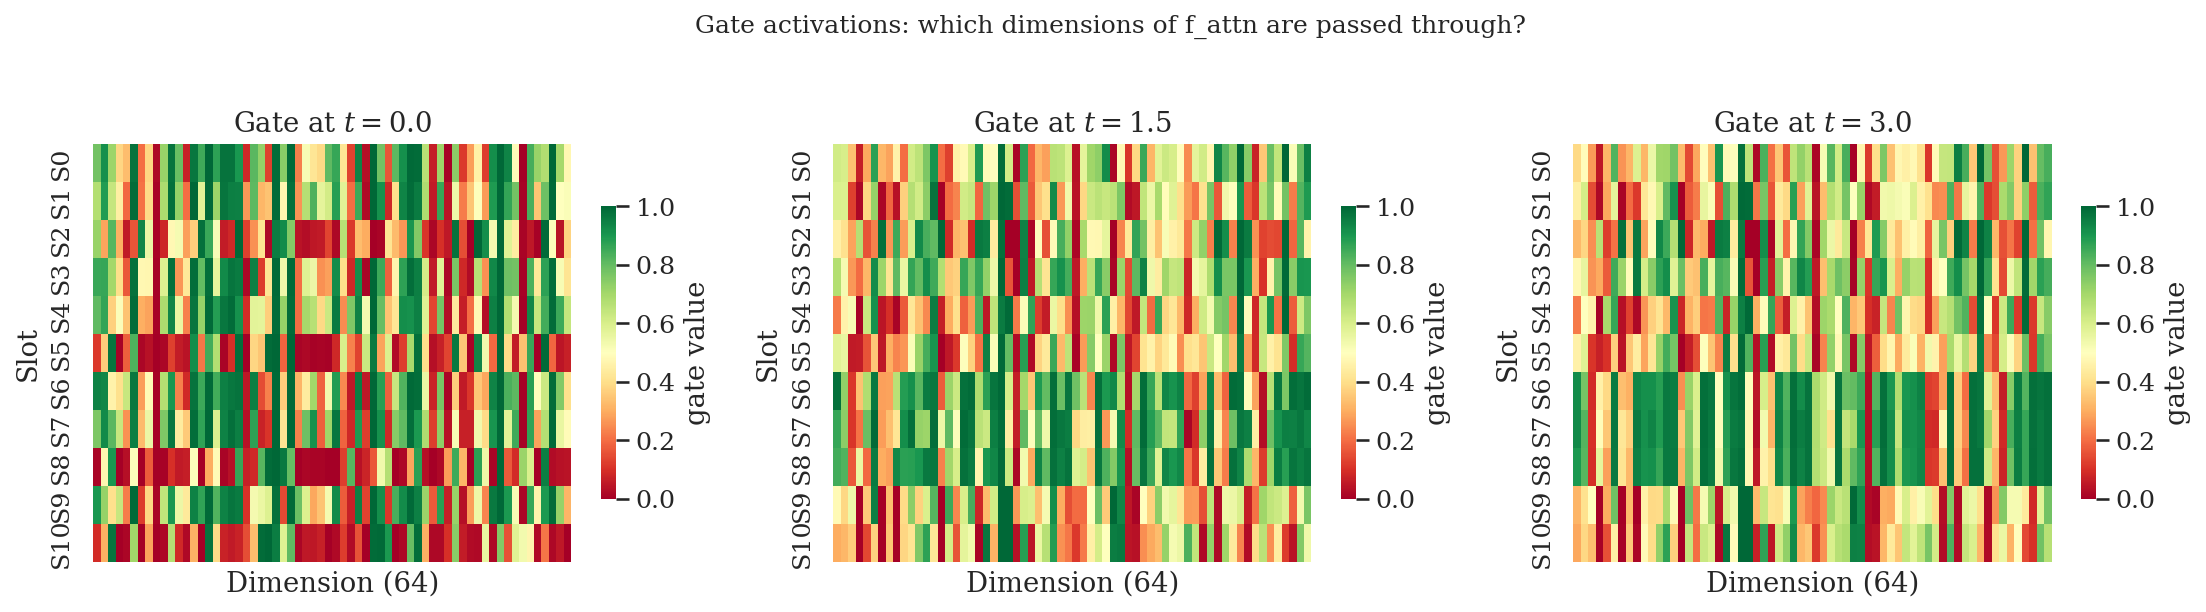

$t = 0.0$: mean=0.509, near-0 (<0.1)=23%, near-1 (>0.9)=23%
$t = 1.5$: mean=0.543, near-0 (<0.1)=11%, near-1 (>0.9)=18%
$t = 3.0$: mean=0.544, near-0 (<0.1)=11%, near-1 (>0.9)=19%


In [9]:
# ── Figure: Gate heatmaps at t=0, T/2, T ───────────────────────────────────
fig, axes = plt.subplots(1, len(t_indices), figsize=(5 * len(t_indices), 4))

for ax, (ti, label) in zip(axes, zip(t_indices, t_labels)):
    gate = intermediates[ti]["gate"]  # [11, 64]
    sns.heatmap(
        gate, ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
        cbar_kws={"shrink": 0.7, "label": "gate value"},
        xticklabels=False,
        yticklabels=[f"S{s}" for s in range(N_SLOTS)],
    )
    ax.set_title(f"Gate at {label}")
    ax.set_xlabel("Dimension (64)")
    ax.set_ylabel("Slot")

fig.suptitle("Gate activations: which dimensions of f_attn are passed through?", fontsize=12, y=1.02)
fig.tight_layout()
plt.show()

# summary stats
for ti, label in zip(t_indices, t_labels):
    gate = intermediates[ti]["gate"]
    print(f"{label}: mean={gate.mean():.3f}, near-0 (<0.1)={np.mean(gate < 0.1)*100:.0f}%, "
          f"near-1 (>0.9)={np.mean(gate > 0.9)*100:.0f}%")

### 3c. Velocity Decomposition — gate * f_attn vs h

The velocity is `gate * f_attn + h`. These are two streams:
- **gate * f_attn**: the attention-driven component — filtered scene information
- **h**: the MLP component — a nonlinear transform of [LayerNorm(slots), f_attn]

How much of the velocity comes from each? Which dominates? Does this change over time?

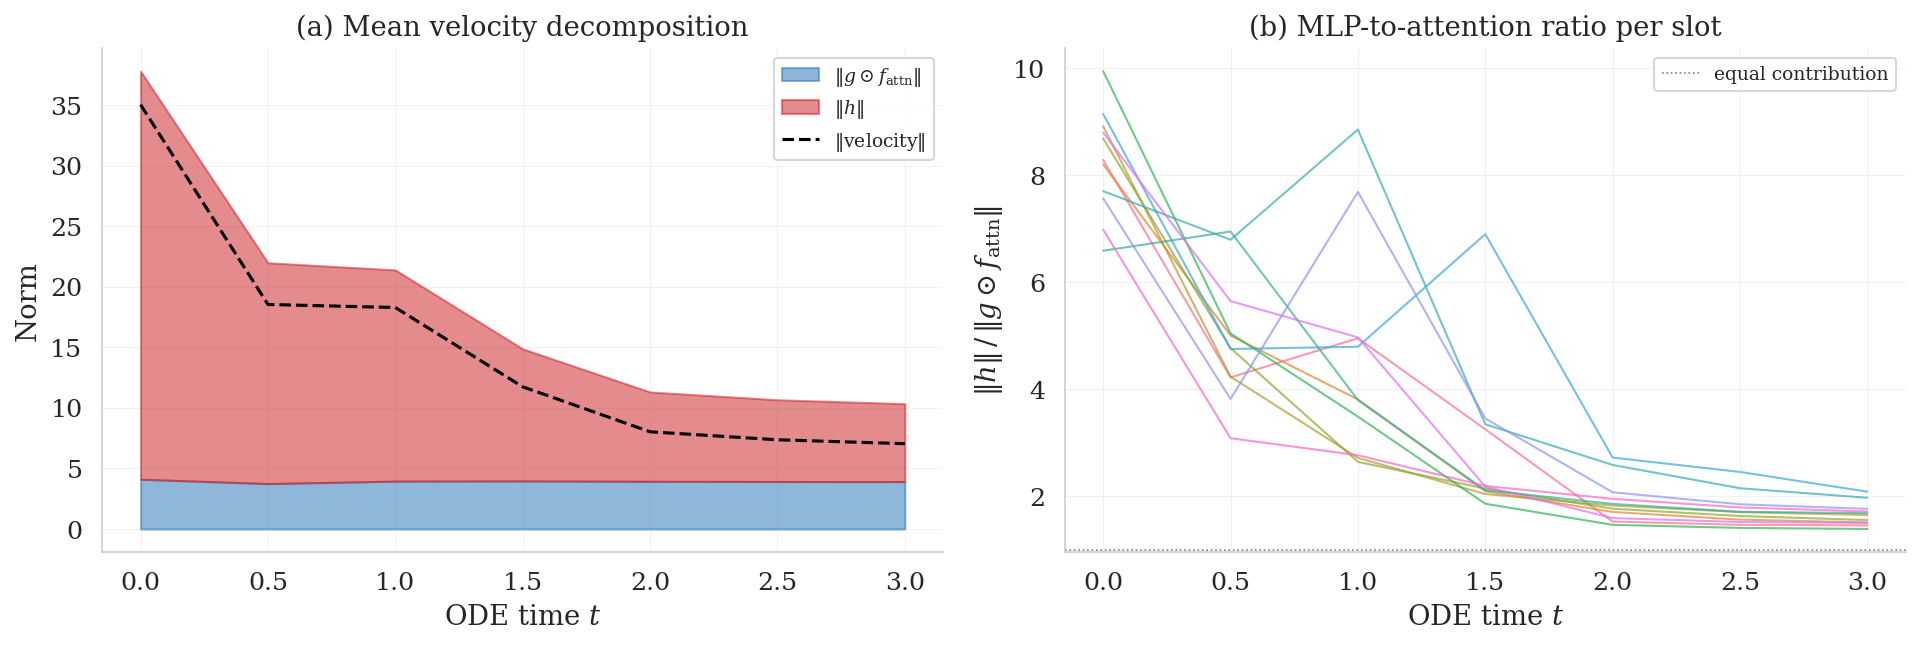

$t = 0.0$: ||h||/||g*f_attn|| = 8.21 — MLP dominates
$t = 1.5$: ||h||/||g*f_attn|| = 2.75 — MLP dominates
$t = 3.0$: ||h||/||g*f_attn|| = 1.64 — MLP dominates


In [10]:
# ── Figure: Velocity decomposition over time ────────────────────────────────

# norms per slot over time
gf_norms = np.zeros((T_PTS, N_SLOTS))  # ||gate * f_attn||
h_norms = np.zeros((T_PTS, N_SLOTS))   # ||h||
vel_norms = np.zeros((T_PTS, N_SLOTS))  # ||velocity||

for t_idx in range(T_PTS):
    gf_norms[t_idx] = np.linalg.norm(intermediates[t_idx]["gate_times_f_attn"], axis=1)
    h_norms[t_idx] = np.linalg.norm(intermediates[t_idx]["h"], axis=1)
    vel_norms[t_idx] = np.linalg.norm(intermediates[t_idx]["velocity"], axis=1)

# (a) stacked area: mean across slots
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
mean_gf = gf_norms.mean(axis=1)
mean_h = h_norms.mean(axis=1)
ax.fill_between(time_values, 0, mean_gf, alpha=0.5, color="#2171b5", label=r"$\|g \odot f_{\mathrm{attn}}\|$")
ax.fill_between(time_values, mean_gf, mean_gf + mean_h, alpha=0.5, color="#cb181d", label=r"$\|h\|$")
ax.plot(time_values, vel_norms.mean(axis=1), color="black", linewidth=1.5, linestyle="--", label=r"$\|\mathrm{velocity}\|$")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel("Norm")
ax.set_title("(a) Mean velocity decomposition")
ax.legend(fontsize=9)

# (b) ratio h / (gate*f_attn) per slot
ax = axes[1]
ratio = h_norms / (gf_norms + 1e-10)
for s_idx in range(N_SLOTS):
    ax.plot(time_values, ratio[:, s_idx], color=SLOT_CMAP[s_idx], linewidth=1, alpha=0.7)
ax.axhline(1.0, color="grey", linewidth=0.8, linestyle=":", label="equal contribution")
ax.set_xlabel("ODE time $t$")
ax.set_ylabel(r"$\|h\| \,/\, \|g \odot f_{\mathrm{attn}}\|$")
ax.set_title("(b) MLP-to-attention ratio per slot")
ax.legend(fontsize=9)

sns.despine()
fig.tight_layout()
plt.show()

# print dominance
for ti, label in zip(t_indices, t_labels):
    r = h_norms[ti].mean() / (gf_norms[ti].mean() + 1e-10)
    dominant = "MLP" if r > 1 else "attention"
    print(f"{label}: ||h||/||g*f_attn|| = {r:.2f} — {dominant} dominates")

### 3d. f_attn — What Does Attention Actually Read?

`f_attn = A @ V` is the weighted average of value vectors, where the weights come from the attention map. This is the "message" from the scene to each slot.

We compare f_attn across slots and over time to see:
- Do different slots read different things? (they should — different objects)
- Does what they read stabilize over time?

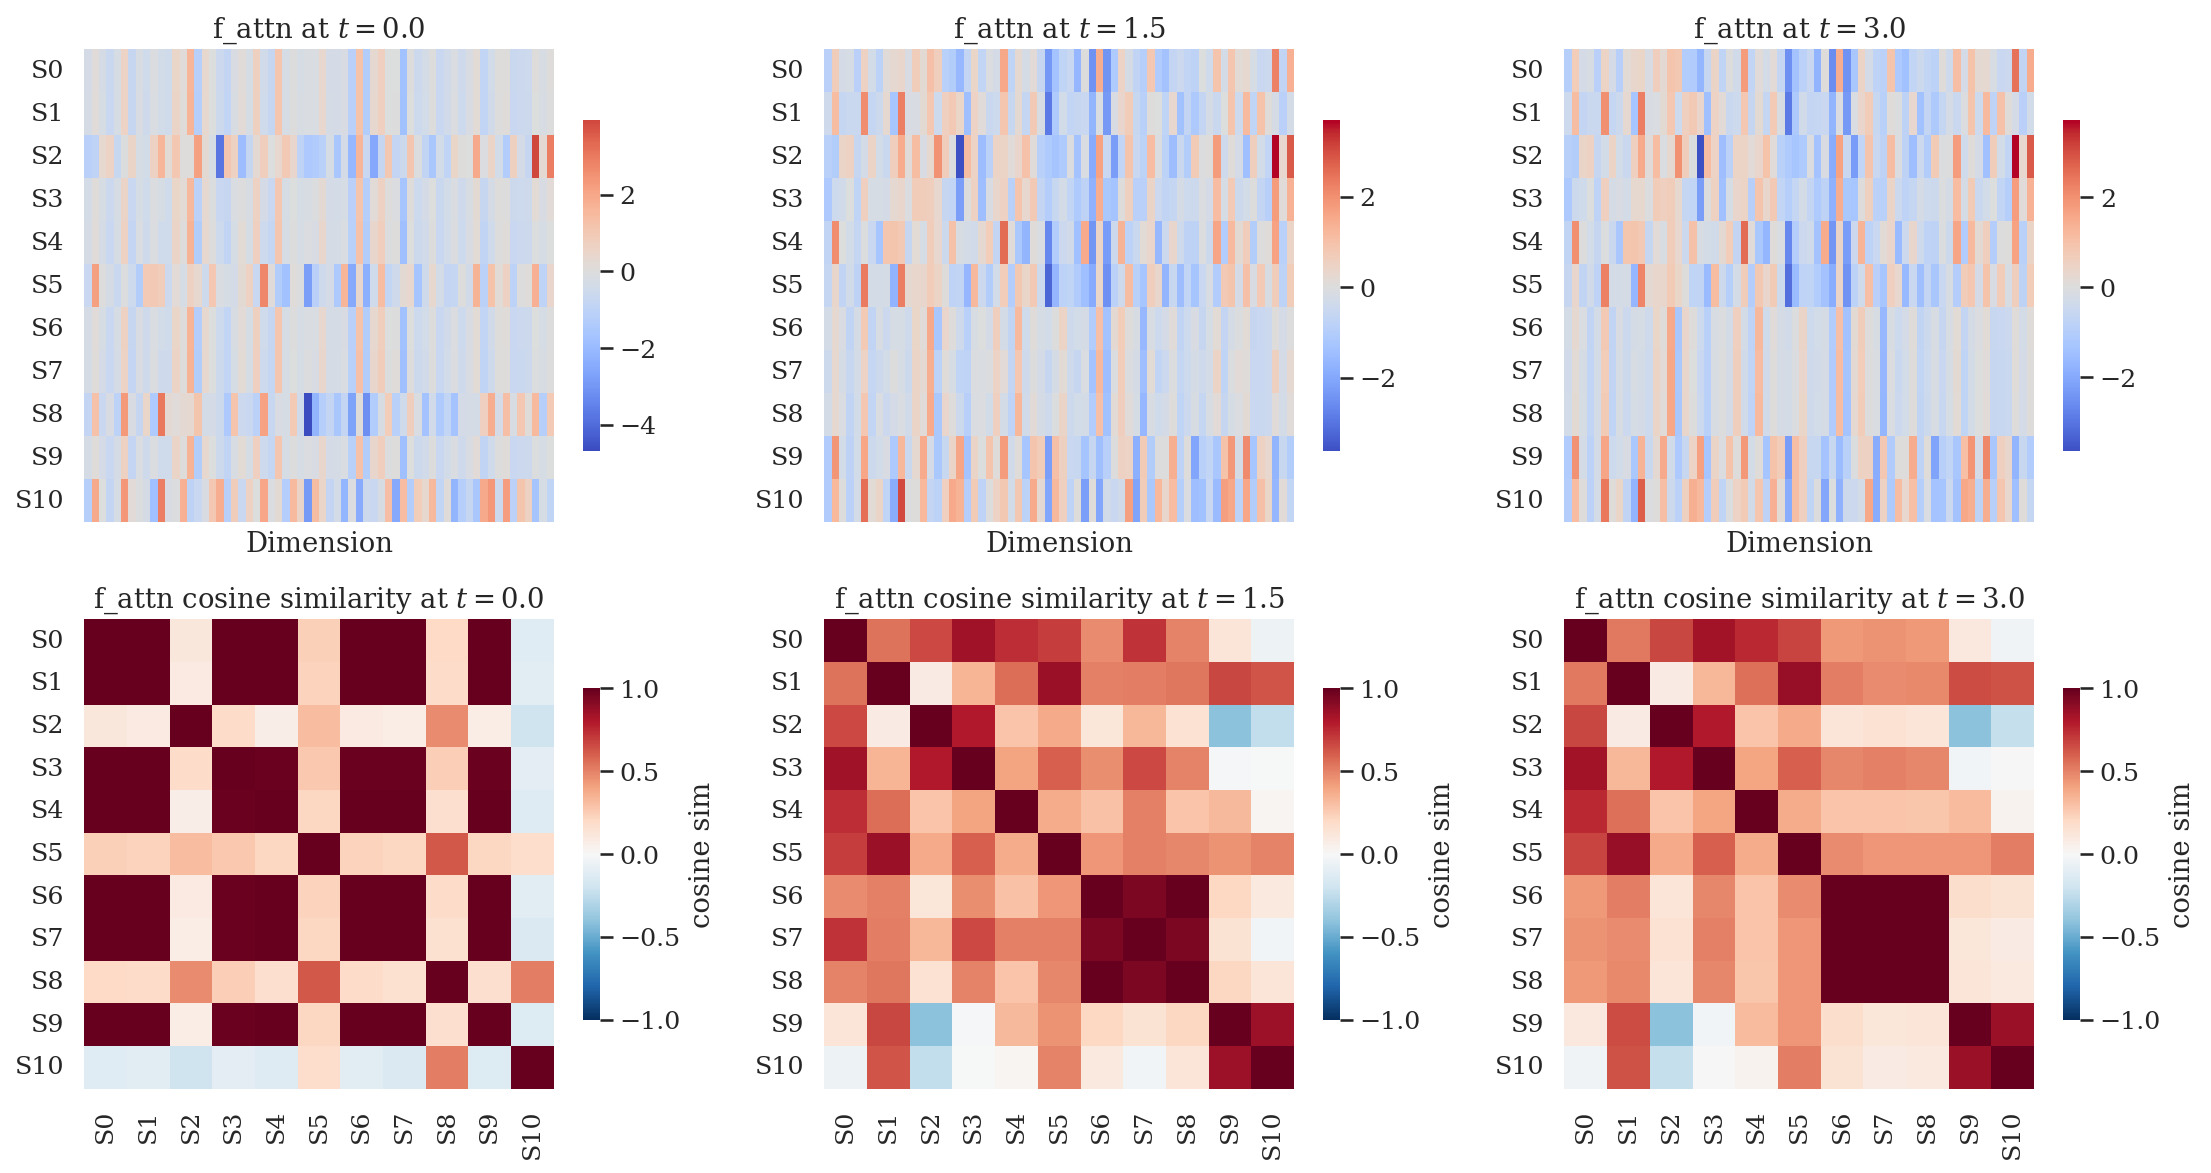

$t = 0.0$: mean off-diag cosine sim = 0.465 (1=identical, 0=orthogonal)
$t = 1.5$: mean off-diag cosine sim = 0.411 (1=identical, 0=orthogonal)
$t = 3.0$: mean off-diag cosine sim = 0.392 (1=identical, 0=orthogonal)


In [11]:
# ── Figure: f_attn heatmaps over time + cosine similarity between slots ─────

fig, axes = plt.subplots(2, len(t_indices), figsize=(5 * len(t_indices), 8))

for col, (ti, label) in enumerate(zip(t_indices, t_labels)):
    f_attn = intermediates[ti]["f_attn"]  # [11, 64]

    # top: heatmap of f_attn
    ax = axes[0, col]
    sns.heatmap(
        f_attn, ax=ax, cmap="coolwarm", center=0,
        xticklabels=False, yticklabels=[f"S{s}" for s in range(N_SLOTS)],
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(f"f_attn at {label}")
    ax.set_xlabel("Dimension")

    # bottom: pairwise cosine similarity between slots' f_attn
    ax = axes[1, col]
    norms = np.linalg.norm(f_attn, axis=1, keepdims=True)
    f_normed = f_attn / (norms + 1e-10)
    cos_sim = f_normed @ f_normed.T  # [11, 11]
    sns.heatmap(
        cos_sim, ax=ax, cmap="RdBu_r", vmin=-1, vmax=1, square=True,
        xticklabels=[f"S{s}" for s in range(N_SLOTS)],
        yticklabels=[f"S{s}" for s in range(N_SLOTS)],
        cbar_kws={"shrink": 0.7, "label": "cosine sim"},
    )
    ax.set_title(f"f_attn cosine similarity at {label}")

fig.tight_layout()
plt.show()

# print: how different are the f_attn vectors across slots?
for ti, label in zip(t_indices, t_labels):
    f_attn = intermediates[ti]["f_attn"]
    norms = np.linalg.norm(f_attn, axis=1, keepdims=True)
    f_normed = f_attn / (norms + 1e-10)
    cos = f_normed @ f_normed.T
    off_diag = cos[np.triu_indices(N_SLOTS, k=1)]
    print(f"{label}: mean off-diag cosine sim = {off_diag.mean():.3f} (1=identical, 0=orthogonal)")

### 3e. Activation Norms Through the Pipeline

Summary of how information magnitude flows through each stage, at t=0 and t=T.

In [12]:
# ── Activation norm summary ─────────────────────────────────────────────────

stages = ["slots_norm", "Q", "f_attn", "gate", "gate_times_f_attn", "h", "velocity"]
stage_labels = ["LayerNorm(slots)", "Q = sn @ W_q", "f_attn = A @ V",
                "gate = σ(...)", "g ⊙ f_attn", "h (MLP)", "velocity"]

print(f"{'Stage':<22} {'t=0 mean||·||':<18} {'t=T mean||·||':<18} {'t=0→T change':>14}")
print("-" * 72)

for stage, label in zip(stages, stage_labels):
    norm_0 = np.linalg.norm(intermediates[0][stage], axis=1).mean()
    norm_T = np.linalg.norm(intermediates[-1][stage], axis=1).mean()
    change = (norm_T - norm_0) / (norm_0 + 1e-10) * 100
    print(f"{label:<22} {norm_0:<18.4f} {norm_T:<18.4f} {change:>+13.1f}%")

# also show slot state norms
slots_0 = traj_np[0, 0]   # [11, 64]
slots_T = traj_np[-1, 0]
print(f"\n{'slots (raw)':<22} {np.linalg.norm(slots_0, axis=1).mean():<18.4f} "
      f"{np.linalg.norm(slots_T, axis=1).mean():<18.4f}")

# MLP hidden layer sparsity (ReLU dead units)
for ti, label in zip([0, T_PTS-1], ["t=0", "t=T"]):
    h_post = intermediates[ti]["h_post_relu"]  # [11, 128]
    dead_frac = np.mean(h_post == 0) * 100
    print(f"MLP hidden ReLU dead units at {label}: {dead_frac:.1f}%")

Stage                  t=0 mean||·||      t=T mean||·||        t=0→T change
------------------------------------------------------------------------
LayerNorm(slots)       8.2479             8.7942                      +6.6%
Q = sn @ W_q           13.9993            27.9310                    +99.5%
f_attn = A @ V         6.6467             7.0970                      +6.8%
gate = σ(...)          4.9553             4.9437                      -0.2%
g ⊙ f_attn             4.1045             3.9108                      -4.7%
h (MLP)                33.6886            6.4326                     -80.9%
velocity               35.0280            7.0409                     -79.9%

slots (raw)            11.8582            27.0824           
MLP hidden ReLU dead units at t=0: 29.2%
MLP hidden ReLU dead units at t=T: 10.2%


## 4. Slot Initialization — What Does the Learned Prior Look Like?

Slots are initialized from `N(mu, exp(log_sigma))` where both mu and log_sigma are learned. This is the starting point of the ODE — the initial condition that the dynamics evolve from.

- What does the learned mu look like? (shared across all slots)
- How large is sigma? (controls diversity of initial slot states)
- How do initialized slots compare to final slots?

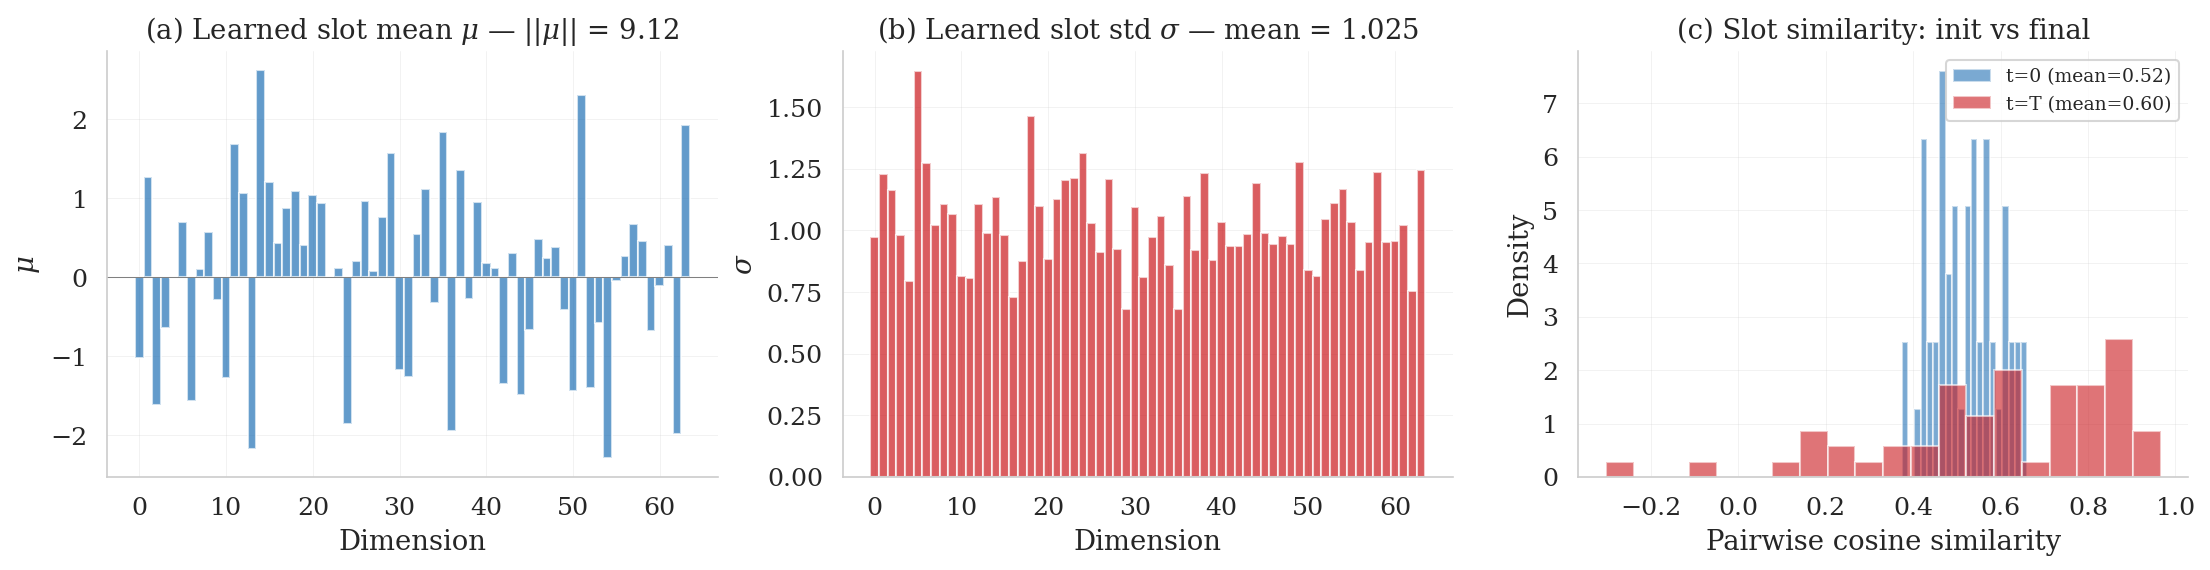

sigma range: [0.680, 1.646], mean: 1.025
Initial slot pairwise cosine: 0.521 (should be high — similar init)
Final slot pairwise cosine: 0.595 (should be lower — differentiated)


In [13]:
# ── Slot initialization parameters ──────────────────────────────────────────
mu = np.array(sa.slots_mu[0, 0])        # [64]
log_sigma = np.array(sa.slots_log_sigma[0, 0])  # [64]
sigma = np.exp(log_sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) mu
ax = axes[0]
ax.bar(range(SLOT_DIM), mu, color="#2171b5", alpha=0.7, width=1.0)
ax.set_xlabel("Dimension")
ax.set_ylabel("$\\mu$")
ax.set_title(f"(a) Learned slot mean $\\mu$ — ||$\\mu$|| = {np.linalg.norm(mu):.2f}")
ax.axhline(0, color="grey", linewidth=0.5)

# (b) sigma
ax = axes[1]
ax.bar(range(SLOT_DIM), sigma, color="#cb181d", alpha=0.7, width=1.0)
ax.set_xlabel("Dimension")
ax.set_ylabel("$\\sigma$")
ax.set_title(f"(b) Learned slot std $\\sigma$ — mean = {sigma.mean():.3f}")

# (c) initial slots vs final slots (cosine similarity)
ax = axes[2]
slots_init = traj_np[0, 0]   # [11, 64]
slots_final = traj_np[-1, 0] # [11, 64]

# pairwise cosine: init slots vs each other, final vs each other
def cos_sim_matrix(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    X_n = X / (norms + 1e-10)
    return X_n @ X_n.T

init_cos = cos_sim_matrix(slots_init)
final_cos = cos_sim_matrix(slots_final)

init_off = init_cos[np.triu_indices(N_SLOTS, k=1)]
final_off = final_cos[np.triu_indices(N_SLOTS, k=1)]

ax.hist(init_off, bins=20, alpha=0.6, color="#2171b5", label=f"t=0 (mean={init_off.mean():.2f})", density=True)
ax.hist(final_off, bins=20, alpha=0.6, color="#cb181d", label=f"t=T (mean={final_off.mean():.2f})", density=True)
ax.set_xlabel("Pairwise cosine similarity")
ax.set_ylabel("Density")
ax.set_title("(c) Slot similarity: init vs final")
ax.legend(fontsize=9)

sns.despine()
fig.tight_layout()
plt.show()

print(f"sigma range: [{sigma.min():.3f}, {sigma.max():.3f}], mean: {sigma.mean():.3f}")
print(f"Initial slot pairwise cosine: {init_off.mean():.3f} (should be high — similar init)")
print(f"Final slot pairwise cosine: {final_off.mean():.3f} (should be lower — differentiated)")